In [31]:
import pandas as pd
import pickle
from utils import *

In [16]:
df_test=pd.read_csv('twitter_test.csv',header=None)
df_test.head()

,0,1,2,3
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [17]:
df_test.rename({0:'id',1:'topic',2:'target',3:'text'},inplace=True,axis=1)
df_test.head()

,id,topic,target,text
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [19]:
df_test.drop(['id','topic'],axis=1,inplace=True)

In [20]:
df_test.head()

,target,text
0,Irrelevant,I mentioned on Facebook that I was struggling ...
1,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,Negative,@Microsoft Why do I pay for WORD when it funct...
3,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,Neutral,Now the President is slapping Americans in the...


In [21]:
df_test.duplicated().sum()

np.int64(1)

In [22]:
df_test.drop_duplicates(inplace=True)

In [23]:
df_test.isna().sum()

target    0
text      0
dtype: int64

In [24]:
df_test['text']=df_test['text'].apply(clean_text)

In [33]:
df_test.to_csv('cleaned_twitter_test.csv')

## Switch Env

In [18]:
import pandas as pd
import pickle

In [19]:
df_test=pd.read_csv('cleaned_twitter_test.csv')
df_test.head()

,Unnamed: 0,target,text
0,0,Irrelevant,mentioned facebook struggling motivation go ru...
1,1,Neutral,bbc news amazon bos jeff bezos reject claim co...
2,2,Negative,microsoft pay word function poorly samsungus c...
3,3,Negative,csgo matchmaking full closet hacking truly awf...
4,4,Neutral,president slapping american face really commit...


In [20]:
df_test=df_test[['target','text']]

In [21]:
import pickle
with open('tokenizer.pkl', 'rb') as f:
    tok = pickle.load(f)


In [22]:
test_sequences = tok.texts_to_sequences(df_test['text'])

In [23]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

test_padded = pad_sequences(test_sequences, maxlen=23, padding='post', truncating='post')


In [24]:
from tensorflow.keras.models import load_model

In [25]:
import tensorflow as tf
from tensorflow.keras import backend as K

def recall_m(y_true, y_pred):
    y_pred = tf.one_hot(tf.argmax(y_pred, axis=-1), depth=tf.shape(y_pred)[-1])
    y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[-1])

    tp = tf.reduce_sum(y_true * y_pred, axis=0)
    fn = tf.reduce_sum(y_true * (1 - y_pred), axis=0)
    recall = tp / (tp + fn + K.epsilon())
    return tf.reduce_mean(recall)

def precision_m(y_true, y_pred):
    y_pred = tf.one_hot(tf.argmax(y_pred, axis=-1), depth=tf.shape(y_pred)[-1])
    y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[-1])

    tp = tf.reduce_sum(y_true * y_pred, axis=0)
    fp = tf.reduce_sum((1 - y_true) * y_pred, axis=0)
    precision = tp / (tp + fp + K.epsilon())
    return tf.reduce_mean(precision)

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2 * ((precision * recall) / (precision + recall + K.epsilon()))


In [26]:
model=load_model('lstm_twitter.h5',custom_objects={
        "recall_m": recall_m,
        "precision_m": precision_m,
        "f1_m": f1_m
    })

In [27]:
df_test['target']=df_test['target'].map({'Positive':0,'Neutral':1,'Negative':2,'Irrelevant':3})

In [28]:
import numpy as np
y = np.array(df_test['target'])

In [32]:
results = model.evaluate(test_padded, y, verbose=1)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9179 - f1_m: 0.9115 - loss: 0.3429 - precision_m: 0.9084 - recall_m: 0.9151
Test Loss: 0.3429
Test Accuracy: 0.9179


In [33]:
print(test_padded.shape, y.shape)



(999, 23) (999,)


In [34]:
y_pred_prob = model.predict(test_padded)
y_pred = y_pred_prob.argmax(axis=1)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [35]:
from sklearn.metrics import classification_report

print(classification_report(y, y_pred))


              precision    recall  f1-score   support

           0       0.89      0.92      0.90       276
           1       0.94      0.92      0.93       285
           2       0.95      0.92      0.94       266
           3       0.88      0.92      0.90       172

    accuracy                           0.92       999
   macro avg       0.92      0.92      0.92       999
weighted avg       0.92      0.92      0.92       999



In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, y_pred)


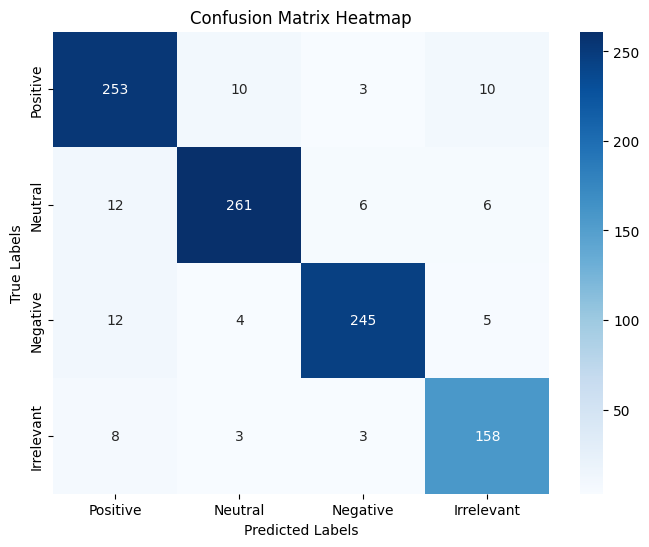

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# If you have class names from LabelEncoder
class_names = ['Positive','Neutral','Negative','Irrelevant']
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()
